In [117]:
print("Example PyTorch Demo to predict game behavior")

Example PyTorch Demo to predict game behavior


In [118]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchview import draw_graph
from torchinfo import summary


In [119]:
print ("Checking any GPU is available")
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")


Checking any GPU is available
Using device: mps


In [120]:
rawData = pd.read_csv("game.csv")
rawData.head()

,health,hasknife,hasgun,enemies,behavior
0,2,0,0,0,wander
1,2,0,0,1,wander
2,2,0,1,1,attack
3,2,0,1,2,attack
4,2,0,1,2,attack


In [121]:
# Convert behavior categories to one-hot columns:
# attack, hide, run, wander
dummies = pd.get_dummies(rawData.behavior)

merged_data = pd.concat([rawData, dummies], axis="columns")

In [123]:
print(merged_data)

    health  hasknife  hasgun  enemies behavior  attack   hide    run  wander
0        2         0       0        0   wander   False  False  False    True
1        2         0       0        1   wander   False  False  False    True
2        2         0       1        1   attack    True  False  False   False
3        2         0       1        2   attack    True  False  False   False
4        2         0       1        2   attack    True  False  False   False
5        2         1       0        2     hide   False   True  False   False
6        2         1       0        1   attack    True  False  False   False
7        1         0       0        0   wander   False  False  False    True
8        1         0       0        1     hide   False   True  False   False
9        1         0       1        1   attack    True  False  False   False
10       1         0       1        2     hide   False   True  False   False
11       1         1       0        2     hide   False   True  False   False

In [124]:
# Input features
inputs = merged_data.drop(
    columns=["behavior", "attack", "hide", "run", "wander"]
)

# Expected outputs
outputs = merged_data.drop(
    columns=["behavior", "health", "hasknife", "hasgun", "enemies"]
)

print(inputs.head())
print(outputs.head())

   health  hasknife  hasgun  enemies
0       2         0       0        0
1       2         0       0        1
2       2         0       1        1
3       2         0       1        2
4       2         0       1        2
   attack   hide    run  wander
0   False  False  False    True
1   False  False  False    True
2    True  False  False   False
3    True  False  False   False
4    True  False  False   False


In [125]:
# ---------------------------------------------------------
# Convert Pandas data to PyTorch tensors
# Tensors can be loaded into a GPU for faster computation
# ---------------------------------------------------------

X = torch.tensor(
    inputs.to_numpy(dtype=np.float32),
    dtype=torch.float32
)

# CrossEntropyLoss wants the class number, not the one-hot row:
# [1,0,0,0] -> 0 (Attack), [0,1,0,0] -> 1 (Hide),
# [0,0,1,0] -> 2 (Run),    [0,0,0,1] -> 3 (Wander)
y = torch.tensor(
    outputs.to_numpy(dtype=np.float32)
).argmax(dim=1)

print(X.shape)
print(y.shape)
print(y)

torch.Size([19, 4])
torch.Size([19])
tensor([3, 3, 0, 0, 0, 1, 0, 3, 1, 0, 1, 1, 1, 3, 1, 1, 2, 2, 1])


In [126]:
# ---------------------------------------------------------
# Randomly split into training (80%) and validation (20%)
# ---------------------------------------------------------

dataset = TensorDataset(X, y)

train_size = int(0.8 * len(dataset))       # 15 rows
val_size = len(dataset) - train_size       # 4 rows

# Fixed seed so the same random split is used every run.
# Remove the generator argument to get a different split each time.
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training rows:   {sorted(train_dataset.indices)}")
print(f"Validation rows: {sorted(val_dataset.indices)}")

# ---------------------------------------------------------
# Create batches
# ---------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=18,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=len(val_dataset),
    shuffle=False
)

Training rows:   [0, 1, 2, 3, 6, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18]
Validation rows: [4, 5, 9, 11]


**Note**: Output of one layer must match the input layer of next.  Internally we are doing a matrix multiplication thus  xn * ny

For example:
nn.Linear(4, 8)
nn.ReLU()

nn.Linear(8, 16)
nn.ReLU()

nn.Linear(16, 4)

In [168]:
# ---------------------------------------------------------
# Define neural network
# ---------------------------------------------------------

model = nn.Sequential(

# This make
# 4, 16, 16, 4.  (4 input, 16 hidden, 16 hidden, 4 output)

    # Input -> first layer
    nn.Linear(4, 6),
    nn.ReLU(),

    
    # Hidden layers
    nn.Linear(6,6),
    nn.ReLU(),


    # Output layer
    nn.Linear(6, 4)
)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=6, bias=True)
  (1): ReLU()
  (2): Linear(in_features=6, out_features=6, bias=True)
  (3): ReLU()
  (4): Linear(in_features=6, out_features=4, bias=True)
)


In [169]:
# ---------------------------------------------------------
# Loss function and optimizer
# ---------------------------------------------------------

# CrossEntropyLoss applies softmax internally, so the model's
# last layer stays a plain nn.Linear (no Softmax layer).
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [170]:
# ---------------------------------------------------------
# Train the network
# ---------------------------------------------------------
print("Examine the loss.  Does it keep decreasing?")
epochs = 5000

for epoch in range(epochs):

    for batch_inputs, batch_outputs in train_loader:

        # Clear gradients from previous iteration
        optimizer.zero_grad()

        # Forward pass
        predictions = model(batch_inputs)

        # Calculate loss
        loss = loss_function(predictions, batch_outputs)

        # Calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs}  "
            f"Loss: {loss.item():.6f}"
        )



Examine the loss.  Does it keep decreasing?
Epoch 500/5000  Loss: 0.401234
Epoch 1000/5000  Loss: 0.031884
Epoch 1500/5000  Loss: 0.008920
Epoch 2000/5000  Loss: 0.003767
Epoch 2500/5000  Loss: 0.001967
Epoch 3000/5000  Loss: 0.001151
Epoch 3500/5000  Loss: 0.000721
Epoch 4000/5000  Loss: 0.000472
Epoch 4500/5000  Loss: 0.000319
Epoch 5000/5000  Loss: 0.000221


In [171]:
# ---------------------------------------------------------
# Prediction function
# ---------------------------------------------------------

def predict(values):

    test = torch.tensor(
        values,
        dtype=torch.float32
    ).reshape(1, 4)

    model.eval()

    with torch.no_grad():
        prediction = model(test)

    # Convert raw outputs to probabilities that add up to 1
    probabilities = torch.softmax(prediction, dim=1)

    print(probabilities.numpy().round(3))

    return probabilities

In [172]:
# note: # The output order is:
# Attack Hide Run Wander

In [173]:
# Test 1
# expected: 0 0 0 1
# Wander

predict([2, 0, 0, 0])

[[0. 0. 0. 1.]]


tensor([[3.6815e-05, 1.7676e-08, 8.6802e-16, 9.9996e-01]])

In [174]:
# Test 2
# expected: 0 1 0 0
# Hide

predict([2, 1, 0, 3])

[[0.    0.999 0.001 0.   ]]


tensor([[8.8285e-06, 9.9937e-01, 6.2251e-04, 1.7863e-12]])

In [175]:
# Test 3
# expected: 1 0 0 0
# Attack

predict([2, 1, 1, 1])

[[1. 0. 0. 0.]]


tensor([[1.0000e+00, 4.2457e-13, 2.7708e-18, 1.6087e-09]])

In [176]:
# Test 4
# expected: 0 1 0 0
# Hide

predict([0, 1, 1, 1])

[[0.009 0.99  0.001 0.   ]]


tensor([[8.7298e-03, 9.9049e-01, 7.8013e-04, 3.5562e-08]])

In [177]:
# Test 5
# expected: 0 0 0 1
# Wander

predict([0, 0, 0, 0])

[[0. 0. 0. 1.]]


tensor([[1.3563e-08, 2.6619e-04, 6.6658e-11, 9.9973e-01]])

In [178]:
 # Test 6
# expected: 0 0 1 0
# Run

predict([0, 1, 0, 3])

[[0. 0. 1. 0.]]


tensor([[6.0213e-16, 7.9652e-07, 1.0000e+00, 7.2861e-20]])

In [179]:
def decode(output):
    behaviors = ["Attack", "Hide", "Run", "Wander"]

    index = torch.argmax(output).item()

    return behaviors[index]

In [180]:
print(decode(predict([0, 1, 0, 3])))

[[0. 0. 1. 0.]]
Run


In [181]:
# ---------------------------------------------------------
# Validate against the held-out validation data
# ---------------------------------------------------------

behaviors = ["Attack", "Hide", "Run", "Wander"]

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_inputs, batch_outputs in val_loader:

        predictions = model(batch_inputs)

        val_loss = loss_function(predictions, batch_outputs)

        for inp, pred, expected in zip(batch_inputs, predictions, batch_outputs):

            # expected is already a class number (0-3)
            is_correct = torch.argmax(pred) == expected
            correct += int(is_correct)
            total += 1

            print(
                f"Input: {inp.int().tolist()}  "
                f"Predicted: {decode(pred):<7}  "
                f"Expected: {behaviors[expected.item()]:<7}  "
                f"{'OK' if is_correct else 'WRONG'}"
            )

print(f"\nValidation loss:     {val_loss.item():.6f}")
print(f"Validation accuracy: {correct}/{total} ({100 * correct / total:.0f}%)")

Input: [2, 0, 1, 2]  Predicted: Attack   Expected: Attack   OK
Input: [1, 0, 1, 1]  Predicted: Attack   Expected: Attack   OK
Input: [2, 1, 0, 2]  Predicted: Hide     Expected: Hide     OK
Input: [1, 1, 0, 2]  Predicted: Hide     Expected: Hide     OK

Validation loss:     0.021830
Validation accuracy: 4/4 (100%)


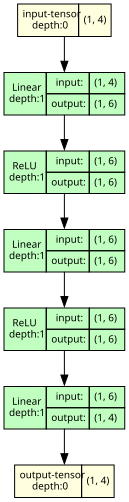

In [182]:

model_graph = draw_graph(
    model,
    input_size=(1, 4)
)

model_graph.visual_graph

In [183]:

summary(model, input_size=(1, 4))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 4]                    --
├─Linear: 1-1                            [1, 6]                    30
├─ReLU: 1-2                              [1, 6]                    --
├─Linear: 1-3                            [1, 6]                    42
├─ReLU: 1-4                              [1, 6]                    --
├─Linear: 1-5                            [1, 4]                    28
Total params: 100
Trainable params: 100
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [184]:

def draw_network(model, input_labels=None, output_labels=None, threshold=0.0):
    
    layers = [layer for layer in model if isinstance(layer, nn.Linear)]

    sizes = [layers[0].in_features]
    sizes += [layer.out_features for layer in layers]

    fig, ax = plt.subplots(figsize=(14, 8))

    x_positions = np.linspace(0, 1, len(sizes))
    neuron_positions = []

    # ---------------------------------------------------------
    # Draw neurons
    # ---------------------------------------------------------

    for layer_num, size in enumerate(sizes):

        y_positions = np.linspace(0, 1, size)
        positions = []

        for neuron_num, y in enumerate(y_positions):

            x = x_positions[layer_num]

            circle = plt.Circle(
                (x, y),
                0.008,
                fill=True,
                zorder=3
            )

            ax.add_patch(circle)

            positions.append((x, y))

            # Label input neurons
            if layer_num == 0 and input_labels is not None:
                ax.text(
                    x - 0.025,
                    y,
                    input_labels[neuron_num],
                    ha="right",
                    va="center",
                    fontsize=11
                )

            # Label output neurons
            if layer_num == len(sizes) - 1 and output_labels is not None:
                ax.text(
                    x + 0.025,
                    y,
                    output_labels[neuron_num],
                    ha="left",
                    va="center",
                    fontsize=11
                )

            # -------------------------------------------------
            # Show bias for every neuron except input neurons
            # -------------------------------------------------

            if layer_num > 0:

                # Linear layer that feeds this neuron
                layer = layers[layer_num - 1]

                bias = layer.bias.detach().cpu().numpy()[neuron_num]

                ax.text(
                    x,
                    y - 0.025,
                    f"b={bias:.2f}",
                    ha="center",
                    va="top",
                    fontsize=8
                )

        neuron_positions.append(positions)


    # ---------------------------------------------------------
    # Draw weighted connections
    # ---------------------------------------------------------

    for layer_num, layer in enumerate(layers):

        weights = layer.weight.detach().cpu().numpy()

        max_weight = np.max(np.abs(weights))

        for destination in range(weights.shape[0]):

            for source in range(weights.shape[1]):

                weight = weights[destination, source]

                if abs(weight) < threshold:
                    continue

                x1, y1 = neuron_positions[layer_num][source]
                x2, y2 = neuron_positions[layer_num + 1][destination]

                strength = abs(weight) / max_weight

                # Exaggerate differences between weak and strong weights
                linewidth = 0.15 + (strength ** 2.5) * 8.0

                # Positive = green, negative = red
                color = "green" if weight >= 0 else "red"

                ax.plot(
                    [x1, x2],
                    [y1, y2],
                    color=color,
                    linewidth=linewidth,
                    alpha=0.5,
                    zorder=1
                )


    # ---------------------------------------------------------
    # Layer labels
    # ---------------------------------------------------------

    ax.text(
        x_positions[0], 1.05,
        "Input",
        ha="center",
        fontsize=12
    )

    for i in range(1, len(sizes) - 1):
        ax.text(
            x_positions[i], 1.05,
            f"Hidden\n{sizes[i]}",
            ha="center",
            fontsize=12
        )

    ax.text(
        x_positions[-1], 1.05,
        "Output",
        ha="center",
        fontsize=12
    )

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.08, 1.1)

    ax.axis("off")

    plt.show()

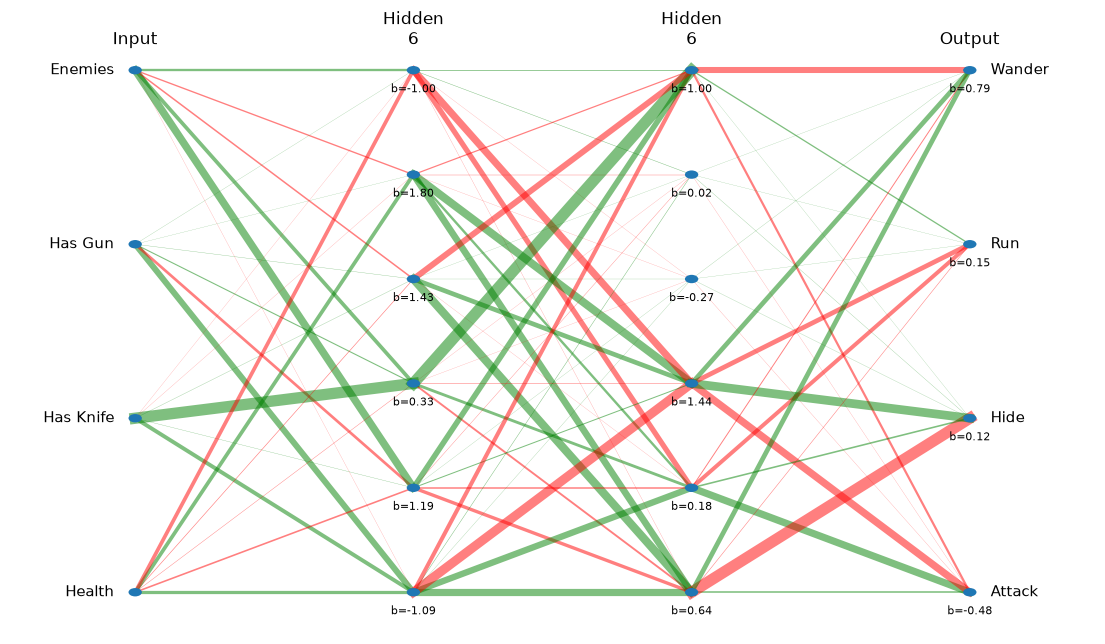

In [185]:
draw_network(
    model,
    input_labels=[
        "Health",
        "Has Knife",
        "Has Gun",
        "Enemies"
    ],
    output_labels=[
        "Attack",
        "Hide",
        "Run",
        "Wander"
    ],
    threshold=0.0
)